In [1]:
import pandas as pd

In [2]:
!pip install pandas

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import sys
!{sys.executable} -m pip install pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("data/sales_data.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,20685,IN-2015-BT1168066-42351,2015-12-13,2015-12-19,Standard Class,BT-1168066,Brian Thompson,Consumer,NaN,Ube,...,OFF-AP-4508,Office Supplies,Appliances,"Hamilton Beach Stove, White",3242.88,6,0.00,421.56,271.59,Medium
1,18072,ES-2015-AB1016545-42351,2015-12-13,2015-12-18,Second Class,AB-1016545,Alan Barnes,Consumer,NaN,Grenoble,...,TEC-PH-3148,Technology,Phones,"Apple Smart Phone, Full Size",1622.34,3,0.15,248.04,168.62,Medium
2,40506,CA-2015-RS19870140-42350,2015-12-12,2015-12-15,Second Class,RS-198701402,Roy Skaria,Home Office,52601.0,Burlington,...,OFF-EN-5580,Office Supplies,Envelopes,Pastel Pink Envelopes,7.28,1,0.00,3.49,1.84,Medium
3,40507,CA-2015-RS19870140-42350,2015-12-12,2015-12-15,Second Class,RS-198701402,Roy Skaria,Home Office,52601.0,Burlington,...,OFF-BI-6391,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,5.40,3,0.00,2.59,1.55,Medium
4,46814,NI-2015-AS22595-42350,2015-12-12,2015-12-16,Standard Class,AS-22595,Alan Schoenberger,Corporate,NaN,Lagos,...,TEC-PH-3818,Technology,Phones,"Cisco Speaker Phone, with Caller ID",41.54,1,0.70,-91.42,1.61,Medium


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          100 non-null    int64  
 1   Order ID        100 non-null    str    
 2   Order Date      100 non-null    str    
 3   Ship Date       100 non-null    str    
 4   Ship Mode       100 non-null    str    
 5   Customer ID     100 non-null    str    
 6   Customer Name   100 non-null    str    
 7   Segment         100 non-null    str    
 8   Postal Code     17 non-null     float64
 9   City            100 non-null    str    
 10  State           100 non-null    str    
 11  Country         100 non-null    str    
 12  Market          100 non-null    str    
 13  Product ID      100 non-null    str    
 14  Category        100 non-null    str    
 15  Sub-Category    100 non-null    str    
 16  Product Name    100 non-null    str    
 17  Sales           100 non-null    float64
 18  Qu

In [7]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Postal Code       83
City               0
State              0
Country            0
Market             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
Shipping Cost      0
Order Priority     0
dtype: int64

In [8]:
df = df.drop('Postal Code', axis=1)

In [9]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Market', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost',
       'Order Priority'],
      dtype='str')

In [10]:
df['Sales'].sum()

np.float64(48375.05)

In [11]:
df['Profit'].sum()

np.float64(7189.3099999999995)

In [12]:
df['Sales'].min()

np.float64(1.79)

In [13]:
df.groupby('Category')['Sales'].sum()

Category
Furniture          20448.99
Office Supplies    17778.11
Technology         10147.95
Name: Sales, dtype: float64

In [14]:
df.groupby('Category')['Profit'].sum()

Category
Furniture          3668.58
Office Supplies    2582.31
Technology          938.42
Name: Profit, dtype: float64

In [15]:
df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head()

Product Name
Cuisinart Stove, Red              1722.48
Bush Classic Bookcase, Pine       1420.02
Brother Wireless Fax, Laser        977.22
Safco Classic Bookcase, Mobile     669.72
Apple Smart Phone, Full Size       604.26
Name: Profit, dtype: float64

In [16]:
import matplotlib.pyplot as plt

In [17]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import matplotlib.pyplot as plt

In [19]:
df.groupby('Category')
['Sales'].sum().plot(kind='bar')

plt.title('Sales by Category')

plt.show()

AttributeError: 'list' object has no attribute 'sum'

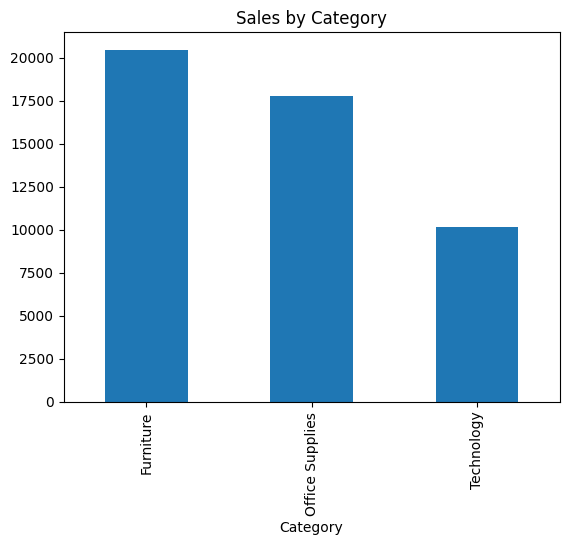

In [20]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')

plt.title('Sales by Category')

plt.show()

In [21]:
df.groupby('Category')[['Sales', 'Profit']].sum()

,Sales,Profit
Category,,
Furniture,20448.99,3668.58
Office Supplies,17778.11,2582.31
Technology,10147.95,938.42


In [22]:
df['Profit Ratio'] = df['Profit'] / df['Sales']
df.groupby('Category')['Profit Ratio'].mean()

Category
Furniture          0.167843
Office Supplies   -0.053590
Technology        -0.189054
Name: Profit Ratio, dtype: float64

In [23]:
df.shape

(100, 23)

In [24]:
df.groupby('Sub-Category')['Profit'].sum().sort_values()

Sub-Category
Machines       -856.73
Tables          -57.74
Paper           -50.26
Supplies        -12.65
Labels           -2.39
Fasteners         2.87
Binders          17.33
Envelopes        61.61
Furnishings      83.70
Accessories     114.07
Art             178.08
Storage         458.27
Chairs          513.38
Phones          669.16
Copiers        1011.92
Appliances     1929.45
Bookcases      3129.24
Name: Profit, dtype: float64

In [25]:
df[df['Sub-Category'] == 'Machines']

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Profit Ratio
26,12441,IT-2015-TT2146064-42230,2015-08-14,2015-08-18,Standard Class,TT-2146064,Tonja Turnell,Home Office,Como,Lombardy,...,Technology,Machines,"Konica Inkjet, Wireless",1316.45,7,0.40,-526.72,91.97,Medium,-0.400106
41,14222,ES-2015-MP17470120-42101,2015-04-07,2015-04-11,Standard Class,MP-17470120,Mark Packer,Home Office,Madrid,Madrid,...,Technology,Machines,"Konica Calculator, Red",175.61,4,0.10,56.57,18.91,High,0.322134
53,13971,ES-2014-DK1283545-41974,2014-12-01,2014-12-05,Second Class,DK-1283545,Damala Kotsonis,Corporate,Strasbourg,Alsace-Champagne-Ardenne-Lorraine,...,Technology,Machines,"Konica Calculator, Red",41.46,1,0.15,11.70,1.46,Medium,0.282200
54,11770,ES-2014-SM2000591-41973,2014-11-30,2014-12-02,First Class,SM-2000591,Sally Matthias,Consumer,Utrecht,Utrecht,...,Technology,Machines,"Okidata Inkjet, Wireless",628.44,4,0.50,-615.96,162.41,Critical,-0.980141
90,48430,HR-2014-KM622530-41670,2014-01-31,2014-02-04,Second Class,KM-622530,Kalyca Meade,Corporate,Zagreb,Grad Zagreb,...,Technology,Machines,"Konica Phone, Wireless",861.90,10,0.00,172.20,78.83,Medium,0.199791
94,30960,IN-2014-AG1027092-41649,2014-01-10,2014-01-11,First Class,AG-1027092,Alejandro Grove,Consumer,Whangarei,Northland,...,Technology,Machines,"Epson Calculator, Wireless",92.82,2,0.00,45.48,14.58,High,0.489981


In [26]:
df.groupby('Discount')['Profit'].mean()

Discount
0.00    170.683404
0.07    155.460000
0.10    120.870000
0.15     98.146667
0.17     10.417500
0.20     17.607857
0.27     21.515000
0.40   -142.003333
0.47   -182.727500
0.50   -327.105000
0.60    -14.196000
0.70    -37.212500
0.80     -3.040000
Name: Profit, dtype: float64

<Axes: xlabel='Discount', ylabel='Profit'>

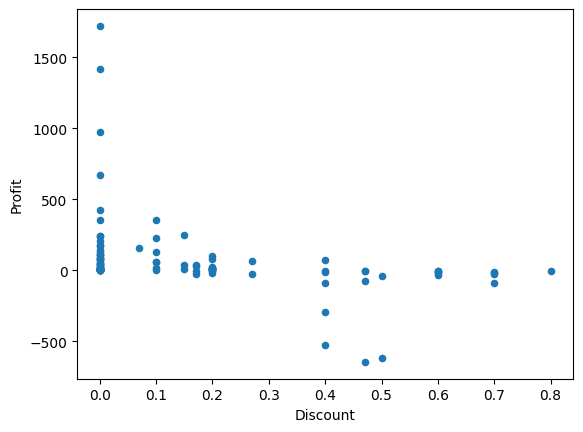

In [27]:
df.plot(x='Discount', y='Profit', kind='scatter')

In [28]:
df.groupby('State')['Profit'].sum().sort_values()

State
Kalimantan Timur                -732.71
Utrecht                         -615.96
Lombardy                        -526.72
Australian Capital Territory    -303.19
Lagos                           -101.66
                                 ...   
New South Wales                  481.87
Tehran                           669.72
Hunan                            977.22
Shizuoka                        1722.48
England                         1739.10
Name: Profit, Length: 73, dtype: float64

In [29]:
df.groupby('State')['Sales'].sum().sort_values()

State
Illinois                           1.79
Zacatecas                          4.32
Connecticut                       11.34
Plateau                           12.66
Iowa                              12.68
                                 ...   
Australian Capital Territory    2550.11
Washington                      2933.68
Yamaguchi                       3242.88
Shizuoka                        4306.32
England                         4460.55
Name: Sales, Length: 73, dtype: float64

In [30]:
df.groupby('State')['Discount'].mean().sort_values(ascending=False).head

<bound method NDFrame.head of State
Illinois        0.8
Plateau         0.7
Lagos           0.7
Enugu           0.7
Izmir           0.6
               ... 
Vienna          0.0
Voronezh        0.0
Western Cape    0.0
Yamaguchi       0.0
Zacatecas       0.0
Name: Discount, Length: 73, dtype: float64>

In [31]:
df.groupby('State')['Discount'].mean().sort_values(ascending=False).head()

State
Illinois    0.8
Plateau     0.7
Lagos       0.7
Enugu       0.7
Izmir       0.6
Name: Discount, dtype: float64

NameError: name 'plit' is not defined

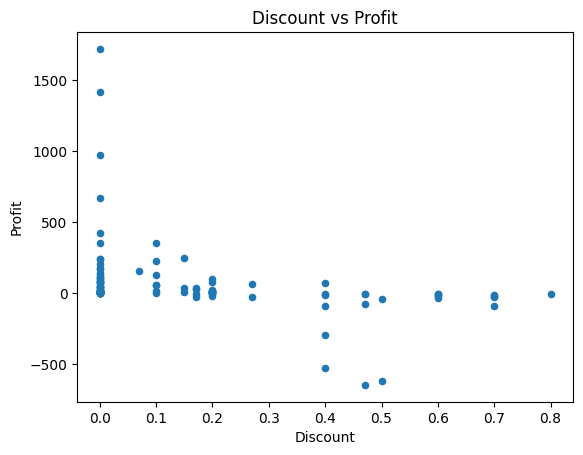

In [32]:
df.plot(x='Discount', y='Profit', kind='scatter')
plt.title('Discount vs Profit')
plit.show()

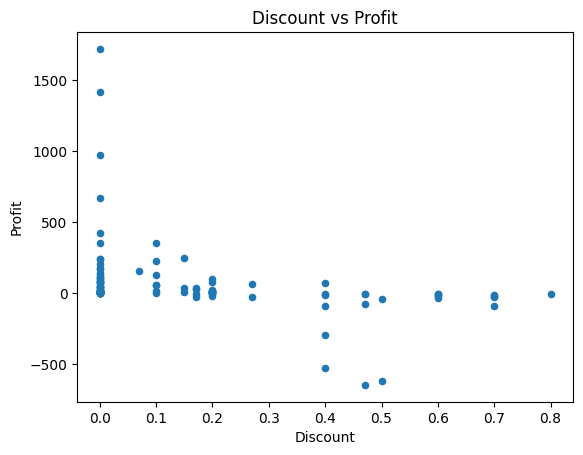

In [33]:
df.plot(x='Discount', y='Profit', kind='scatter')
plt.title('Discount vs Profit')
plt.show()

In [34]:
df.groupby('States')['Discount'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top States with Highest Discount')
plt.show()

KeyError: 'States'

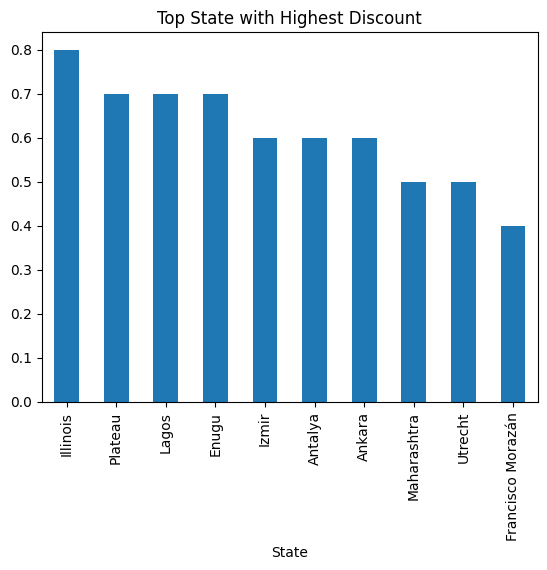

In [35]:
df.groupby('State')['Discount'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top State with Highest Discount')
plt.show()